In [12]:
import pandas as pd
import pymc as pm
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
import pytensor as pt

df = pd.read_csv('data.csv', keep_default_na=False, na_values=[''])
df.head()

,name,yearEstablished,state,stateAbbreviation,locationType,locationTypeKind,typeOwned,typeProfit,level,hasUndergraduate,...,closedByRegion_2024,totalByState_2025,closedByState_2025,totalByRegion_2025,closedByRegion_2025,regionUnemploymentRate,totalByStateMean,totalByRegionMean,closedByStateMean,closedByRegionMean
0,Alderson Broaddus University,1871,West Virginia,WV,Rural,Distant,Private,Nonprofit,4-year,True,...,4,65,0,2035,2,3.6,68.0,2050.25,0.50,1.50
1,Alliance University (Formerly Nyack College),1882,New York,NY,City,Large,Private,Nonprofit,4-year,True,...,8,399,0,1129,0,4.1,412.0,1157.50,1.00,2.25
2,Ancilla College,1937,Indiana,IN,Rural,Distant,Private,Nonprofit,2-year,True,...,9,98,0,1279,4,4.1,101.0,1314.25,0.25,3.25
3,Becker College,1784,Massachusetts,MA,City,Midsize,Private,Nonprofit,4-year,True,...,8,138,0,1129,0,4.1,141.5,1157.50,0.50,2.25
4,Bloomfield College,1868,New Jersey,NJ,Suburb,Large,Private,Nonprofit,4-year,True,...,8,142,0,1129,0,4.1,144.0,1157.50,0.25,2.25


In [14]:
n_s = df.groupby('region')['totalByRegion_2020'].mean().round(0).astype(int)
y_s = df['region'].value_counts()

all_regions = pd.Index(list(n_s.index) + list(y_s.index)).unique()
n_s = n_s.reindex(all_regions)
y_s = y_s.reindex(all_regions)

# variable inflation factor (VIF)
# no frequent approach

a = 2 # 55
b = 2 # 4000
# (2,2) will put center of the prior at 0.5

a_post = a + y_s
b_post = b + n_s - y_s

post_means = a_post / (a_post + b_post)
post_vars = (a_post * b_post) / ((a_post + b_post)**2 * (a_post + b_post + 1))

results = pd.DataFrame({
    'n_s': n_s,
    'y_s': y_s,
    'a_post': a_post,
    'b_post': b_post,
    'post_mean': post_means,
    'post_var': post_vars
})
print(results)

            n_s  y_s  a_post  b_post  post_mean  post_var
Midwest    1322   26      28    1298   0.021116  0.000016
Northeast  1163   17      19    1148   0.016281  0.000014
South      2054   12      14    2044   0.006803  0.000003
West       1254   10      12    1246   0.009539  0.000008


In [15]:
trace = az.from_netcdf('traces/trace_multilayer_region.nc')
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,-1.696,0.607,-2.848,-0.624,0.007,0.010,9847.0,5733.0,1.0
x_s_raw[0],0.015,0.965,-1.825,1.822,0.007,0.008,16756.0,11726.0,1.0
x_s_raw[1],0.015,0.965,-1.775,1.865,0.008,0.008,15599.0,11030.0,1.0
x_s_raw[2],-0.027,0.955,-1.748,1.845,0.008,0.008,16100.0,11381.0,1.0
x_s_raw[3],-0.012,0.978,-1.874,1.803,0.008,0.009,15902.0,10425.0,1.0
sigma,0.262,0.416,0.001,0.935,0.006,0.017,9336.0,6125.0,1.0
k,0.254,0.207,0.000,0.631,0.002,0.002,8811.0,5236.0,1.0
p_s[0],0.020,0.004,0.013,0.027,0.000,0.000,17652.0,10643.0,1.0
p_s[1],0.015,0.004,0.009,0.021,0.000,0.000,15882.0,11066.0,1.0
p_s[2],0.006,0.002,0.003,0.009,0.000,0.000,16474.0,9940.0,1.0


In [16]:
a_post_samples = trace.posterior['a_s'].values + y_s.values[None, None, :] # Shape: (chains, draws, states)
b_post_samples = trace.posterior['b_s'].values + (n_s.values - y_s.values)[None, None, :]

post_means = a_post_samples.mean(axis=(0, 1)) / (a_post_samples.mean(axis=(0, 1)) + b_post_samples.mean(axis=(0, 1)))
post_vars = (a_post_samples.mean(axis=(0, 1)) * b_post_samples.mean(axis=(0, 1))) / (
    (a_post_samples.mean(axis=(0, 1)) + b_post_samples.mean(axis=(0, 1)))**2 * 
    (a_post_samples.mean(axis=(0, 1)) + b_post_samples.mean(axis=(0, 1)) + 1)
)

results = pd.DataFrame({
    'n_s': n_s,
    'y_s': y_s,
    'a_post': a_post_samples.mean(axis=(0, 1)),
    'b_post': b_post_samples.mean(axis=(0, 1)),
    'post_mean': post_means,
    'post_var': post_vars
}, index=all_regions).reset_index().rename(columns={'index': 'region'})

print(results)

      region   n_s  y_s     a_post       b_post  post_mean  post_var
0    Midwest  1322   26  26.221420  1296.695703   0.019821  0.000015
1  Northeast  1163   17  17.220526  1146.695517   0.014795  0.000013
2      South  2054   12  12.216307  2042.693075   0.005945  0.000003
3       West  1254   10  10.217332  1244.693689   0.008142  0.000006


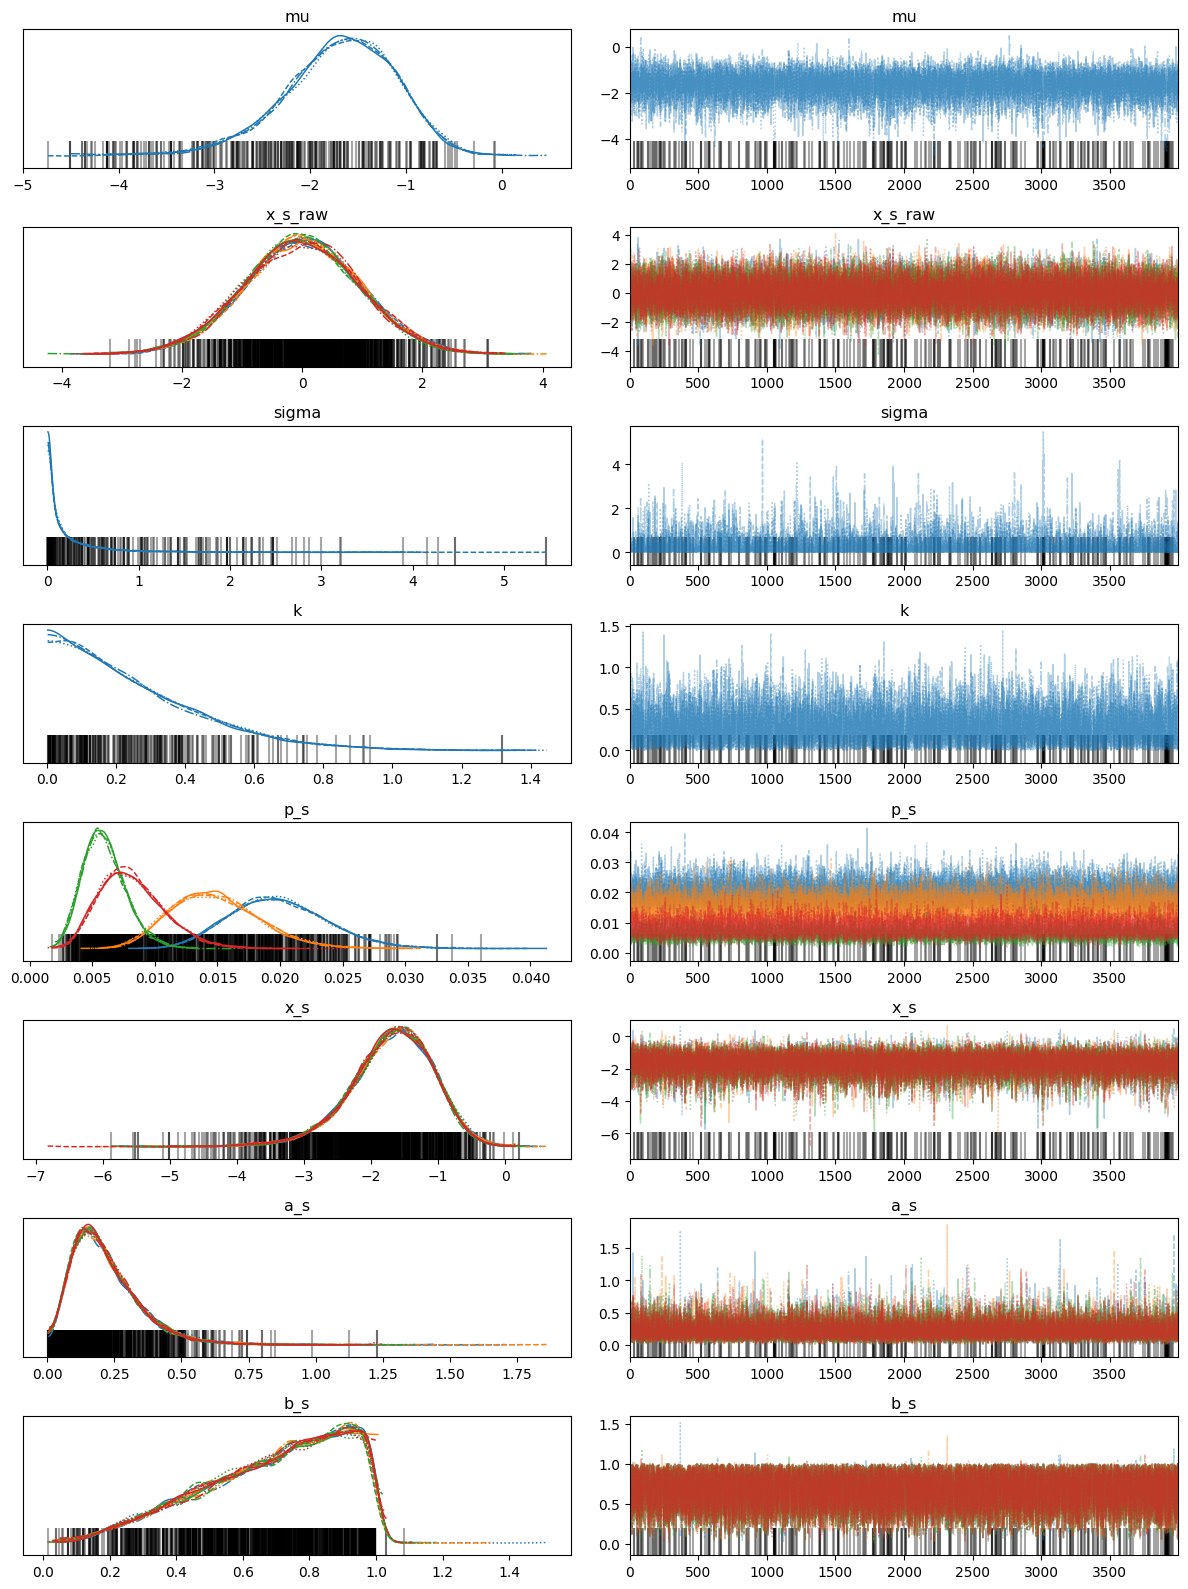

In [6]:
az.plot_trace(trace)
plt.tight_layout()
plt.show()

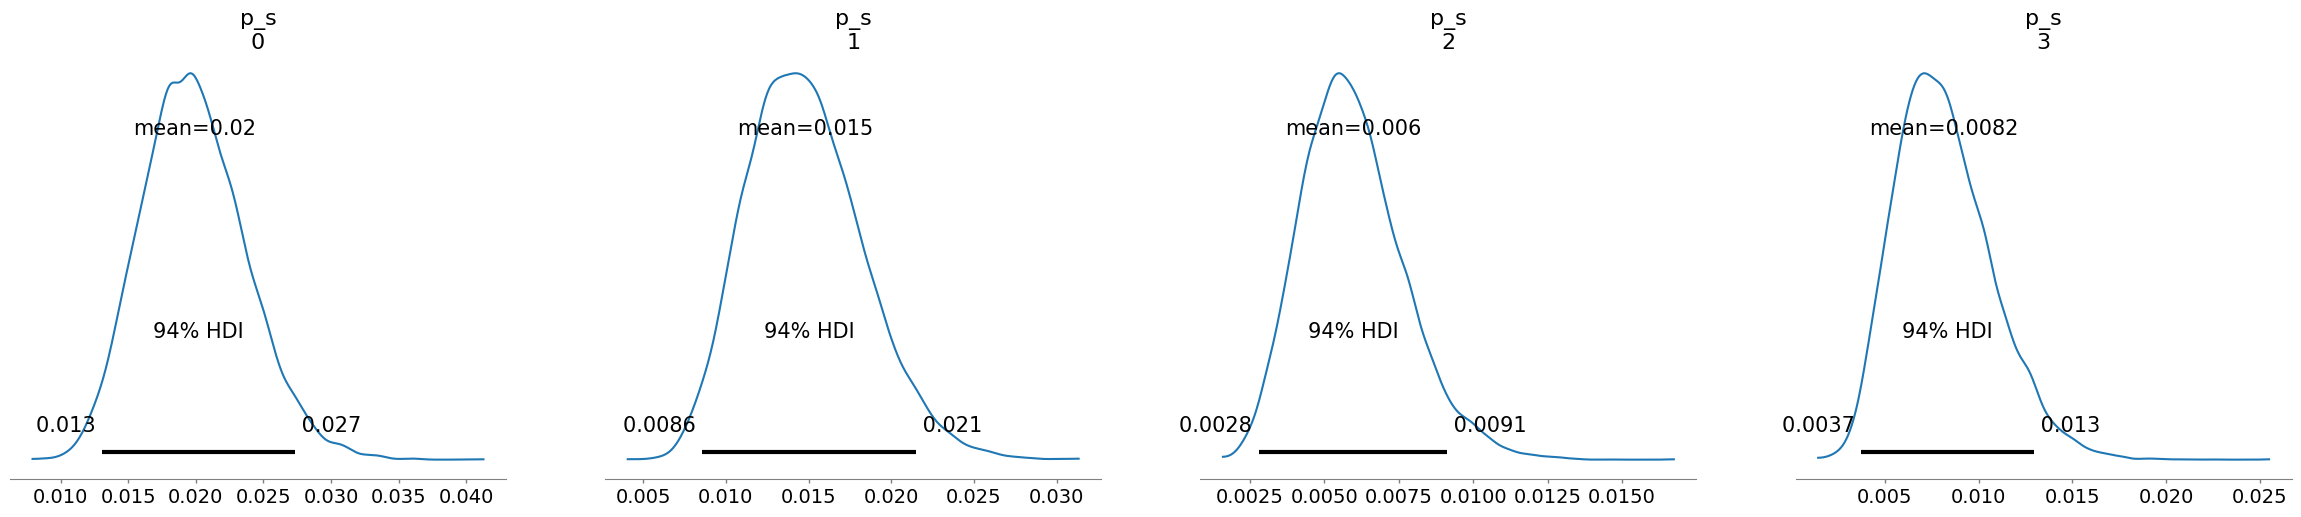

In [7]:
az.plot_posterior(trace, var_names=['p_s'])
plt.show()

### only-one layer

In [17]:
trace = az.from_netcdf('traces/trace_simple_region.nc')
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a_s[0],0.824,1.217,0.000,2.874,0.011,0.025,7780.0,7376.0,1.0
a_s[1],0.726,1.023,0.000,2.430,0.009,0.020,7947.0,7385.0,1.0
a_s[2],0.433,0.578,0.000,1.431,0.005,0.010,7921.0,7015.0,1.0
a_s[3],0.511,0.713,0.000,1.695,0.007,0.014,6907.0,6357.0,1.0
b_s[0],29.576,49.564,0.000,115.578,0.439,0.966,8843.0,8732.0,1.0
b_s[1],31.877,52.440,0.000,125.647,0.445,0.955,8899.0,8173.0,1.0
b_s[2],31.702,55.396,0.000,128.828,0.447,0.939,8687.0,8096.0,1.0
b_s[3],32.497,55.024,0.000,129.386,0.453,0.882,8652.0,8361.0,1.0
p_s[0],0.020,0.004,0.013,0.027,0.000,0.000,14171.0,9869.0,1.0
p_s[1],0.015,0.004,0.009,0.022,0.000,0.000,13928.0,10199.0,1.0


In [18]:
a_post_samples = trace.posterior['a_s'].values + y_s.values[None, None, :]  # Shape: (chains, draws, states)
b_post_samples = trace.posterior['b_s'].values + (n_s.values - y_s.values)[None, None, :]

post_means = a_post_samples.mean(axis=(0, 1)) / (a_post_samples.mean(axis=(0, 1)) + b_post_samples.mean(axis=(0, 1)))
post_vars = (a_post_samples.mean(axis=(0, 1)) * b_post_samples.mean(axis=(0, 1))) / (
    (a_post_samples.mean(axis=(0, 1)) + b_post_samples.mean(axis=(0, 1)))**2 * 
    (a_post_samples.mean(axis=(0, 1)) + b_post_samples.mean(axis=(0, 1)) + 1)
)

results = pd.DataFrame({
    'n_s': n_s,
    'y_s': y_s,
    'a_post': a_post_samples.mean(axis=(0, 1)),
    'b_post': b_post_samples.mean(axis=(0, 1)),
    'post_mean': post_means,
    'post_var': post_vars
}, index=all_regions).reset_index().rename(columns={'index': 'region'})

print(results)

      region   n_s  y_s     a_post       b_post  post_mean  post_var
0    Midwest  1322   26  26.824268  1325.575703   0.019835  0.000014
1  Northeast  1163   17  17.726381  1177.877097   0.014826  0.000012
2      South  2054   12  12.433179  2073.701741   0.005960  0.000003
3       West  1254   10  10.511087  1276.496824   0.008167  0.000006


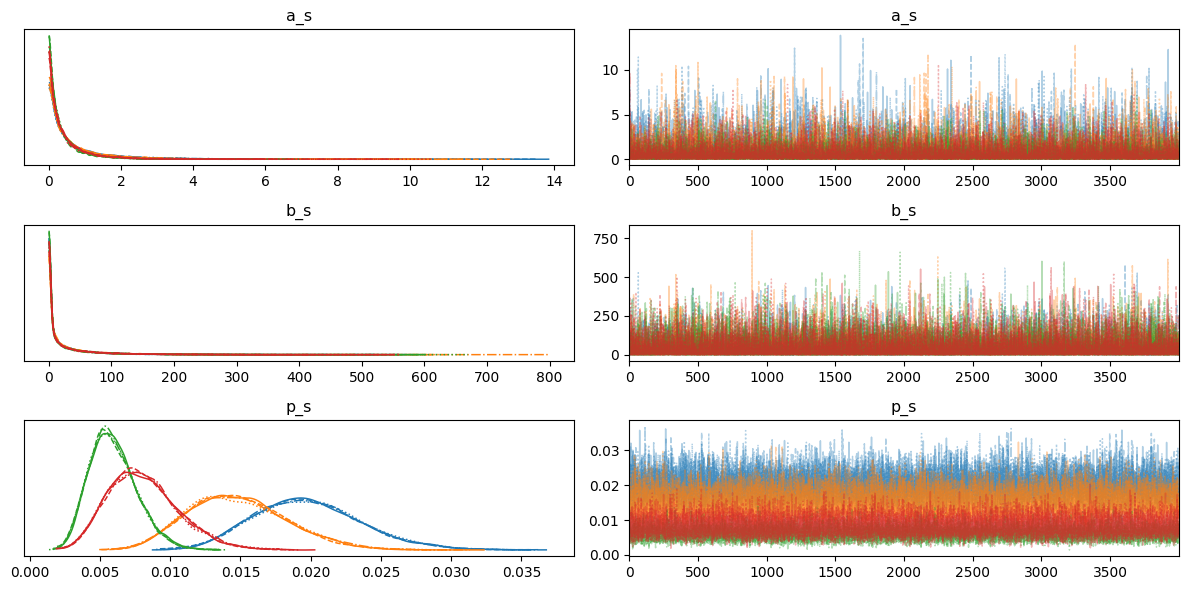

In [10]:
az.plot_trace(trace)
plt.tight_layout()
plt.show()

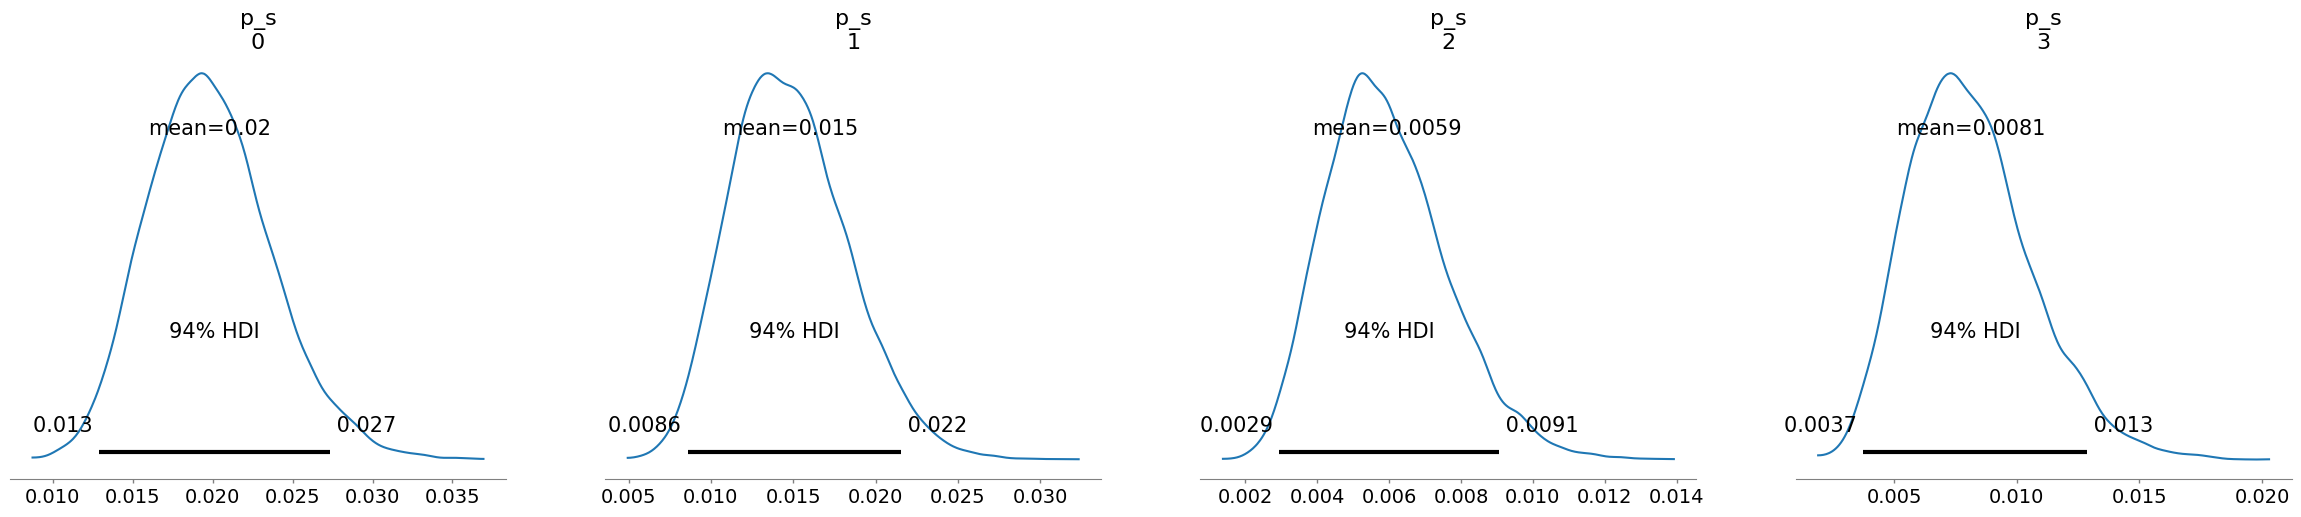

In [11]:
az.plot_posterior(trace, var_names=['p_s'])
plt.show()